In [25]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [26]:
# =========================================
# 2. LOAD DATA
# =========================================

# Load Excel dataset
data = pd.read_excel(r"../df.xlsx")

# Remove unwanted rows (adjust if needed)
df = data.iloc[27:, :]

# Ensure data is in time order
df = df.sort_values("Date")

# Set date as index
df.set_index("Date", inplace=True)

# Select time series column
ts = df["Sown_Extent_Total"]

In [27]:
# =========================================
# 3. TRAIN / VALIDATION / TEST SPLIT
# =========================================

train_size = int(len(ts) * 0.7)
val_size = int(len(ts) * 0.1)
test_size = int(len(ts)*0.2)
train = ts.iloc[:train_size]
validation = ts.iloc[train_size:train_size + val_size]
test = ts.iloc[train_size:]

In [28]:
# =========================================
# 4. NORMALIZATION (VERY IMPORTANT)
# =========================================

scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit ONLY on training data (avoids data leakage)
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
validation_scaled = scaler.transform(validation.values.reshape(-1, 1))
test_scaled = scaler.transform(test.values.reshape(-1, 1))

# Convert to PyTorch tensors
train_scaled = torch.FloatTensor(train_scaled).view(-1)
validation_scaled = torch.FloatTensor(validation_scaled).view(-1)
test_scaled = torch.FloatTensor(test_scaled).view(-1)

In [29]:
# =========================================
# 5. CREATE SEQUENCES (SLIDING WINDOW)
# =========================================

# LSTM needs input-output pairs like:
# [t1, t2, t3, t4] → t5

def create_sequences(data, seq_len):
    sequences = []
    for i in range(len(data) - seq_len):
        x = data[i:i+seq_len]
        y = data[i+seq_len:i+seq_len+1]
        sequences.append((x, y))
    return sequences


seq_len = 5

train_seq = create_sequences(train_scaled, seq_len)
val_seq = create_sequences(validation_scaled, seq_len)

In [30]:
# =========================================
# 6. BUILD LSTM MODEL
# =========================================

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, output_size=1):
        super().__init__()

        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size)

        # Fully connected layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):

        # reshape input for LSTM
        x = x.view(len(x), 1, -1)

        lstm_out, _ = self.lstm(x)

        # take last output
        out = self.fc(lstm_out[-1])

        return out


model = LSTMModel()

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [31]:
# =========================================
# 7. TRAINING + VALIDATION LOOP
# =========================================

epochs = 80

train_losses = []
val_losses = []

for epoch in range(epochs):

    # ----------------------
    # TRAINING
    # ----------------------
    model.train()
    train_loss = 0

    for seq, label in train_seq:

        optimizer.zero_grad()

        y_pred = model(seq)

        loss = loss_fn(y_pred, label)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_losses.append(train_loss / len(train_seq))


    # ----------------------
    # VALIDATION
    # ----------------------
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for seq, label in val_seq:
            y_pred = model(seq)
            loss = loss_fn(y_pred, label)
            val_loss += loss.item()

    val_losses.append(val_loss / len(val_seq))


    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_losses[-1]:.6f} | "
          f"Val Loss: {val_losses[-1]:.6f}")

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/80 | Train Loss: 0.371513 | Val Loss: 0.384269
Epoch 2/80 | Train Loss: 0.319730 | Val Loss: 0.439128
Epoch 3/80 | Train Loss: 0.298778 | Val Loss: 0.414276
Epoch 4/80 | Train Loss: 0.259677 | Val Loss: 0.306322
Epoch 5/80 | Train Loss: 0.122045 | Val Loss: 0.034720
Epoch 6/80 | Train Loss: 0.112464 | Val Loss: 0.077084
Epoch 7/80 | Train Loss: 0.099246 | Val Loss: 0.070502
Epoch 8/80 | Train Loss: 0.095803 | Val Loss: 0.065111
Epoch 9/80 | Train Loss: 0.091842 | Val Loss: 0.058082
Epoch 10/80 | Train Loss: 0.087166 | Val Loss: 0.046774
Epoch 11/80 | Train Loss: 0.081670 | Val Loss: 0.031100
Epoch 12/80 | Train Loss: 0.075445 | Val Loss: 0.013711
Epoch 13/80 | Train Loss: 0.069440 | Val Loss: 0.001982
Epoch 14/80 | Train Loss: 0.064879 | Val Loss: 0.000427
Epoch 15/80 | Train Loss: 0.061970 | Val Loss: 0.003780
Epoch 16/80 | Train Loss: 0.060124 | Val Loss: 0.006621
Epoch 17/80 | Train Loss: 0.058837 | Val Loss: 0.008250
Epoch 18/80 | Train Loss: 0.057844 | Val Loss: 0.009226
E

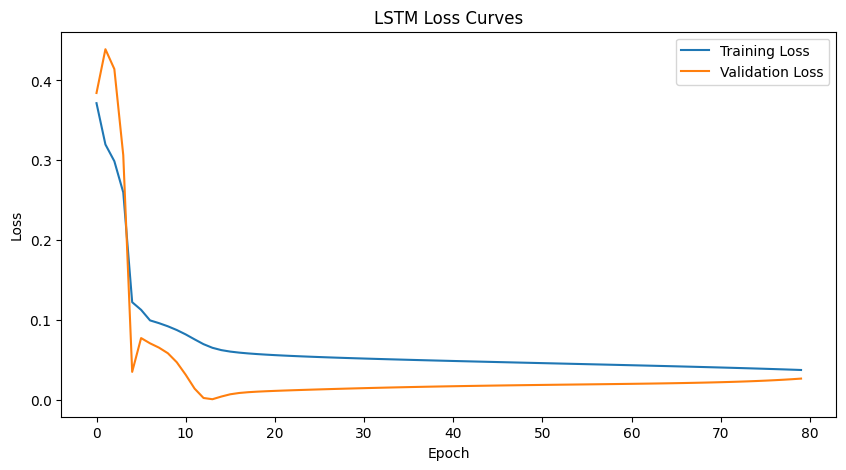

In [32]:
# =========================================
# 8. LOSS CURVES
# =========================================

plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("LSTM Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [33]:
# =========================================
# 9. FORECASTING (TEST DATA)
# =========================================

model.eval()

predictions = []

input_seq = train_scaled[-seq_len:].clone()

with torch.no_grad():

    for i in range(len(test)):

        y_pred = model(input_seq)

        predictions.append(y_pred.item())

        # update sequence (sliding window)
        input_seq = torch.cat((input_seq[1:], y_pred.view(1)))

In [34]:
# =========================================
# 10. INVERSE TRANSFORM
# =========================================

predictions = np.array(predictions).reshape(-1, 1)
predictions = scaler.inverse_transform(predictions)

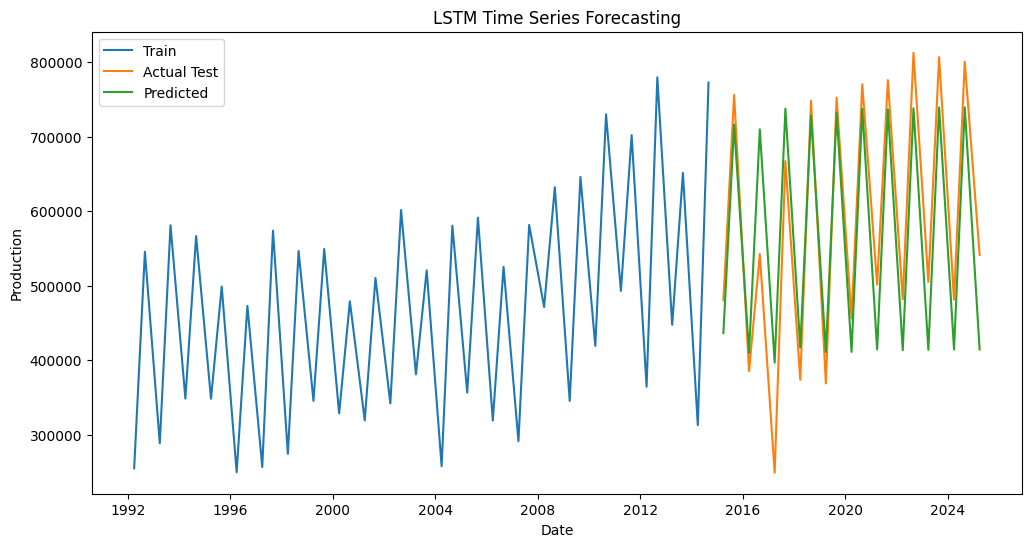

In [35]:
# =========================================
# 11. PLOT RESULTS
# =========================================

plt.figure(figsize=(12,6))

plt.plot(train.index, train.values, label="Train")
# plt.plot(validation.index, validation.values, label="Validation")
plt.plot(test.index, test.values, label="Actual Test")
plt.plot(test.index, predictions, label="Predicted")

plt.title("LSTM Time Series Forecasting")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.show()

In [36]:
# =========================================
# 12. MODEL EVALUATION
# =========================================

y_true = test.values
y_pred = predictions.reshape(-1)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
r2 = r2_score(y_true, y_pred)

print("\n===== MODEL PERFORMANCE =====")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")


===== MODEL PERFORMANCE =====
MAE  : 65693.1057
RMSE : 76517.8230
MAPE : 13.38%
R²   : 0.8012
